# Assignment 1 — Environment & First Network

**DATAX504** · Due end of Week 2 · **NumPy only** (no Keras/TensorFlow for the network)

## Tasks
1. Document OpenCode setup (screenshot or log in `opencode_setup/` folder)
2. Train a 2-layer dense network on synthetic data below
3. Plot training loss over 100 epochs
4. Write a ~200-word reflection on OpenCode use

## Moodle fields
`a1_repo`, `a1_loss_final`, `a1_params`, `a1_opencode_model`, `a1_reflection`

## AI disclosure

| Field | Your answer                   |
|-------|-------------------------------|
| Tool | OpenCode Desktop+ GPT-5.6 Sol |
| Used for |                               |
| Verified how |                               |
| Not used for |                               |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(504)
plt.rcParams["figure.figsize"] = (8, 4)

## 1. Synthetic dataset

Two moons–style binary classification in 2D (non-linear boundary).

X shape: (1000, 2) y shape: (1000, 1)


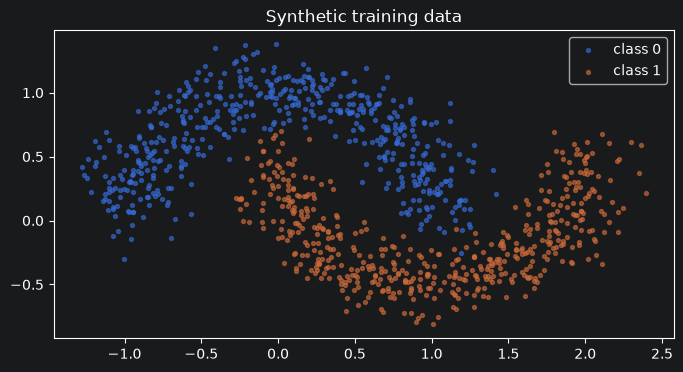

In [2]:
def make_moons(n_samples=1000, noise=0.15):
    """Simple two-moons dataset. Returns X (n, 2), y (n, 1)."""
    n = n_samples // 2
    theta = np.linspace(0, np.pi, n)
    moon1 = np.c_[np.cos(theta), np.sin(theta)]
    moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5]
    X = np.vstack([moon1, moon2])
    X += np.random.randn(*X.shape) * noise
    y = np.vstack([np.zeros((n, 1)), np.ones((n, 1))])
    return X.astype(np.float32), y.astype(np.float32)

X, y = make_moons(1000)
print("X shape:", X.shape, "y shape:", y.shape)

plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], s=8, alpha=0.6, label="class 0")
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], s=8, alpha=0.6, label="class 1")
plt.legend()
plt.title("Synthetic training data")
plt.show()

## 2. Activation functions

In [ ]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

## 3. Network parameters

Architecture: **2 inputs → 16 hidden (ReLU) → 1 output (sigmoid)**

Use He initialisation for `W1` and a small scale for `W2`.

In [ ]:
input_size, hidden_size, output_size = 2, 16, 1
learning_rate = 0.1
epochs = 100

# TODO: initialise W1, b1, W2, b2
W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size), dtype=np.float32)
W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * 0.01
b2 = np.zeros((1, output_size), dtype=np.float32)

total_params = W1.size + b1.size + W2.size + b2.size
print(f"Total trainable parameters: {total_params}")  # → Moodle a1_params

## 4. Forward & backward pass

Implement one training step. Hint: binary cross-entropy loss gradient at sigmoid output simplifies to `(A2 - y) / m`.

In [ ]:
def forward(X, W1, b1, W2, b2):
    """Return cache dict with intermediates for backprop."""
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return {"Z1": Z1, "A1": A1, "A2": A2}

def backward(X, y, cache, W2):
    """Return gradients dW1, db1, dW2, db2."""
    m = X.shape[0]
    A1, A2 = cache["A1"], cache["A2"]
    # TODO: complete backpropagation
    dZ2 = (A2 - y) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

def compute_loss(y, A2):
    eps = 1e-8
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))

## 5. Training loop

In [ ]:
loss_history = []

for epoch in range(epochs):
    cache = forward(X, W1, b1, W2, b2)
    loss = compute_loss(y, cache["A2"])
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward(X, y, cache, W2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  loss = {loss:.4f}")

final_loss = loss_history[-1]
print(f"\nFinal loss (Moodle a1_loss_final): {final_loss:.4f}")

In [ ]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss — Assignment 1")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Reflection (Moodle `a1_reflection`)

Write ~200 words:
- One thing OpenCode helped with
- One thing it got wrong or you had to fix
- How you verified the final notebook

*Your reflection here (or paste into Moodle form).*